## Load Taxi Data

In [3]:
import os
import time
import pandas as pd
from sodapy import Socrata
from datetime import date, timedelta

APP_TOKEN   = "xwqrqc987doRPgtIuryvxM2Ls"
DATASET_ID  = "ajtu-isnz"
OUTPUT_FILE = "../data/chicago_taxi_2025.csv"
CHECKPOINT_FILE = "../data/download_checkpoint_2025.txt"

# pickup_centroid_location / dropoff_centroid_location werden weggelassen –
# sie duplizieren die separaten Latitude/Longitude-Spalten als Point-Objekt.
COLUMNS = [
    "trip_id",
    "taxi_id",
    "trip_start_timestamp",
    "trip_end_timestamp",
    "trip_seconds",
    "trip_miles",
    "pickup_census_tract",
    "dropoff_census_tract",
    "pickup_community_area",
    "dropoff_community_area",
    "fare",
    "tips",
    "tolls",
    "extras",
    "trip_total",
    "payment_type",
    "company",
    "pickup_centroid_latitude",
    "pickup_centroid_longitude",
    "dropoff_centroid_latitude",
    "dropoff_centroid_longitude",
]

CHUNK_DAYS  = 7      # Wochenchunks – klein genug für schnelle Serverantwort
BATCH_SIZE  = 50_000
MAX_RETRIES = 8
START_DATE  = date(2025, 1, 1)
END_DATE    = date(2025, 12, 31)


def load_checkpoint_date():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE) as f:
            d = date.fromisoformat(f.read().strip())
        print(f"  Checkpoint gefunden: Starte ab {d}")
        return d
    return START_DATE


def save_checkpoint_date(d):
    with open(CHECKPOINT_FILE, "w") as f:
        f.write(d.isoformat())


def append_to_csv(df, filepath):
    write_header = not os.path.exists(filepath)
    df.to_csv(filepath, mode="a", index=False, header=write_header)


def check_columns_match(filepath, expected_columns):
    """Prüft ob die Spalten der bestehenden CSV mit COLUMNS übereinstimmen."""
    with open(filepath, "r") as f:
        header = f.readline().strip().split(",")
    return header == expected_columns


def cast_types(df):
    df["trip_start_timestamp"] = pd.to_datetime(df["trip_start_timestamp"], errors="coerce")
    df["trip_end_timestamp"]   = pd.to_datetime(df["trip_end_timestamp"],   errors="coerce")
    for col in ["trip_seconds", "trip_miles", "fare", "tips", "tolls", "extras", "trip_total",
                "pickup_centroid_latitude",  "pickup_centroid_longitude",
                "dropoff_centroid_latitude", "dropoff_centroid_longitude",
                "pickup_community_area",     "dropoff_community_area"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def download_taxi_2025():
    # ── Spalten-Konsistenz-Check ───────────────────────────────────────────────
    # Sicherheitsnetz: Wenn eine alte CSV mit anderen Spalten existiert und kein
    # Checkpoint vorhanden ist, würde ein Resume die Datei mit falschen Spalten
    # weiterschreiben und korrupte Daten erzeugen.
    # → In diesem Fall wird die alte Datei gelöscht und neu gestartet.
    if os.path.exists(OUTPUT_FILE) and not os.path.exists(CHECKPOINT_FILE):
        if not check_columns_match(OUTPUT_FILE, COLUMNS):
            print(f"  WARNUNG: Bestehende CSV hat andere Spalten als COLUMNS.")
            print(f"  Alte Datei wird gelöscht und Download neu gestartet.")
            os.remove(OUTPUT_FILE)
        else:
            print(f"  Bestehende CSV gefunden, aber kein Checkpoint – starte neu.")
            os.remove(OUTPUT_FILE)

    print("Verbinde mit Chicago Data Portal...")
    client = Socrata("data.cityofchicago.org", APP_TOKEN, timeout=180)

    current = load_checkpoint_date()
    select_clause = ", ".join(COLUMNS)
    total_rows = 0

    while current <= END_DATE:
        chunk_end = min(current + timedelta(days=CHUNK_DAYS), END_DATE + timedelta(days=1))
        where = (
            f"trip_start_timestamp >= '{ current.isoformat() }T00:00:00'"
            f" AND trip_start_timestamp < '{ chunk_end.isoformat() }T00:00:00'"
        )

        offset = 0
        while True:
            # Retry-Loop
            results = None
            for attempt in range(1, MAX_RETRIES + 1):
                try:
                    results = client.get(
                        DATASET_ID,
                        select=select_clause,
                        where=where,
                        limit=BATCH_SIZE,
                        offset=offset,
                    )
                    break
                except Exception as e:
                    wait = 3 * (2 ** (attempt - 1))
                    print(f"  ✗ Versuch {attempt}/{MAX_RETRIES}: {e}")
                    if attempt < MAX_RETRIES:
                        print(f"    Warte {wait}s...")
                        time.sleep(wait)
                    else:
                        print(f"  Abbruch. Checkpoint bei {current}.")
                        save_checkpoint_date(current)
                        return

            if not results:
                break  # Kein Ergebnis in diesem Zeitfenster

            chunk = cast_types(pd.DataFrame.from_records(results))
            chunk = chunk[COLUMNS]
            append_to_csv(chunk, OUTPUT_FILE)

            offset     += len(results)
            total_rows += len(results)

            size_mb = os.path.getsize(OUTPUT_FILE) / 1e6
            print(f"  ✓ {current} – {chunk_end}  |  +{len(results):,} Zeilen  |  gesamt {total_rows:,}  |  {size_mb:.0f} MB")

            if len(results) < BATCH_SIZE:
                break  # Letzter Batch dieses Zeitfensters

        save_checkpoint_date(chunk_end)  # Nächste Woche beginnen
        current = chunk_end
        time.sleep(0.3)

    if os.path.exists(OUTPUT_FILE):
        final_size = os.path.getsize(OUTPUT_FILE) / 1e6
        print(f"── Fertig ─────────────────────────────────────────")
        print(f"  Datei  : {os.path.abspath(OUTPUT_FILE)}")
        print(f"  Groesse: {final_size:.1f} MB")
        print(f"  Zeilen : {total_rows:,}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)


download_taxi_2025()

Verbinde mit Chicago Data Portal...
  Checkpoint gefunden: Starte ab 2025-02-19
  ✓ 2025-02-19 – 2025-02-26  |  +50,000 Zeilen  |  gesamt 50,000  |  253 MB
  ✓ 2025-02-19 – 2025-02-26  |  +50,000 Zeilen  |  gesamt 100,000  |  270 MB
  ✓ 2025-02-19 – 2025-02-26  |  +21,072 Zeilen  |  gesamt 121,072  |  277 MB
  ✓ 2025-02-26 – 2025-03-05  |  +50,000 Zeilen  |  gesamt 171,072  |  294 MB
  ✓ 2025-02-26 – 2025-03-05  |  +50,000 Zeilen  |  gesamt 221,072  |  311 MB
  ✓ 2025-02-26 – 2025-03-05  |  +25,913 Zeilen  |  gesamt 246,985  |  320 MB
  ✓ 2025-03-05 – 2025-03-12  |  +50,000 Zeilen  |  gesamt 296,985  |  337 MB
  ✓ 2025-03-05 – 2025-03-12  |  +50,000 Zeilen  |  gesamt 346,985  |  354 MB
  ✓ 2025-03-05 – 2025-03-12  |  +21,753 Zeilen  |  gesamt 368,738  |  362 MB
  ✓ 2025-03-12 – 2025-03-19  |  +50,000 Zeilen  |  gesamt 418,738  |  379 MB
  ✓ 2025-03-12 – 2025-03-19  |  +50,000 Zeilen  |  gesamt 468,738  |  396 MB
  ✓ 2025-03-12 – 2025-03-19  |  +41,570 Zeilen  |  gesamt 510,308  |  410 

## Load weather data

In [14]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude":  41.8781,   # Chicago
    "longitude": -87.6298,
    "start_date": "2025-01-01",
    "end_date":   "2025-12-31",
    "hourly": [
        "temperature_2m",
        "apparent_temperature",
        "precipitation",
        "snowfall",
        "wind_speed_10m",
        "cloud_cover",
        "weather_code",
    ],
    "timezone": "America/Chicago",  # lokale Zeit, passt zu den Taxidaten
    "wind_speed_unit": "mph",
}

response = requests.get(url, params=params)
data     = response.json()

# WMO Weather Code → human-readable description (Open-Meteo uses WMO standard)
WMO_CODES = {
    0:  "Clear sky",
    1:  "Mainly clear",
    2:  "Partly cloudy",
    3:  "Overcast", # bedeckt
    45: "Fog",
    48: "Rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Heavy freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snowfall",
    73: "Moderate snowfall",
    75: "Heavy snowfall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail",
}

# In DataFrame umwandeln
df_weather = pd.DataFrame(data["hourly"])
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather = df_weather.rename(columns={"time": "datetime"})

df_weather["weather_description"] = df_weather["weather_code"].map(WMO_CODES).fillna("Unknown")

print(f"Rows: {len(df_weather)}")   # should be 8760 (365 days × 24h)
print(df_weather[["datetime", "weather_code", "weather_description"]].head(10))

df_weather.to_csv("../data/chicago_weather_2025_hourly.csv", index=False)
print("Saved as ../data/chicago_weather_2025_hourly.csv")

Rows: 8760
             datetime  weather_code weather_description
0 2025-01-01 00:00:00             3            Overcast
1 2025-01-01 01:00:00             3            Overcast
2 2025-01-01 02:00:00             3            Overcast
3 2025-01-01 03:00:00            71     Slight snowfall
4 2025-01-01 04:00:00             3            Overcast
5 2025-01-01 05:00:00             3            Overcast
6 2025-01-01 06:00:00             3            Overcast
7 2025-01-01 07:00:00             3            Overcast
8 2025-01-01 08:00:00             0           Clear sky
9 2025-01-01 09:00:00             0           Clear sky
Saved as ../data/chicago_weather_2025_hourly.csv


## Data Cleaning – Taxi-Daten

Bevor wir filtern oder transformieren, schauen wir uns zunächst an, *was* eigentlich im Rohdatensatz steckt: Wie vollständig sind die einzelnen Spalten? Welche Werte kommen vor – und welche fehlen? Diese Analyse motiviert jeden der folgenden Cleaning-Schritte.

Rohdatensatz: 6,825,838 Zeilen × 21 Spalten

                            Null-Werte  Anteil (%)  Gefüllt (%)
dropoff_census_tract           3833960        56.2         43.8
pickup_census_tract            3745884        54.9         45.1
dropoff_community_area          587236         8.6         91.4
dropoff_centroid_longitude      552728         8.1         91.9
dropoff_centroid_latitude       552728         8.1         91.9
pickup_centroid_longitude       183365         2.7         97.3
pickup_centroid_latitude        183365         2.7         97.3
pickup_community_area           186736         2.7         97.3
tolls                            11637         0.2         99.8
trip_total                       11637         0.2         99.8
extras                           11637         0.2         99.8
fare                             11637         0.2         99.8
tips                             11637         0.2         99.8
taxi_id                              9         0.0        1

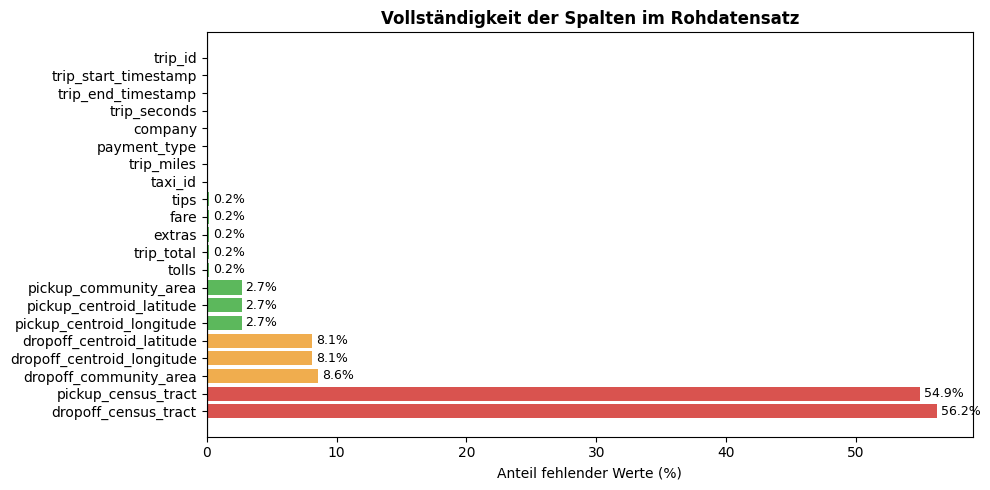

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH    = '../data/chicago_taxi_2025.csv'
OUT_PARQUET = '../data/chicago_taxi_2025_clean.parquet'

# ── Laden ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, low_memory=False)
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], errors='coerce')
df['trip_end_timestamp']   = pd.to_datetime(df['trip_end_timestamp'],   errors='coerce')
df = df[df['trip_start_timestamp'].dt.year == 2025].copy()
print(f"Rohdatensatz: {len(df):,} Zeilen × {df.shape[1]} Spalten\n")

# ── Null-Werte pro Spalte ─────────────────────────────────────────────────────
null_counts = df.isnull().sum()
null_pcts   = (df.isnull().mean() * 100).round(1)

overview = pd.DataFrame({
    'Null-Werte':  null_counts,
    'Anteil (%)':  null_pcts,
    'Gefüllt (%)': (100 - null_pcts),
}).sort_values('Anteil (%)', ascending=False)

print(overview.to_string())

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f' if p > 30 else '#f0ad4e' if p > 5 else '#5cb85c' for p in overview['Anteil (%)']]
bars = ax.barh(overview.index, overview['Anteil (%)'], color=colors)
ax.set_xlabel('Anteil fehlender Werte (%)')
ax.set_title('Vollständigkeit der Spalten im Rohdatensatz', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, overview['Anteil (%)']):
    if val > 0:
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Hinweis: Census Tracts – Vollständigkeit & Nutzbarkeit

Die Übersicht zeigt, dass `pickup_census_tract` und `dropoff_census_tract` bei rund 55 % der Trips fehlen. Das ist kein zufälliger Fehler — Chicago maskiert Census Tracts absichtlich aus Datenschutzgründen, wenn zu wenige Fahrten auf einen Tract entfallen. Community Areas bieten eine niedrigere geografische Auflösung, aber mit nahezu vollständiger Abdeckung.

Die Spalten bleiben im Dataset erhalten; Analysen, die eine flächendeckende geografische Abdeckung erfordern, sollten jedoch auf die Community Areas zurückgreifen.

In [5]:
coverage_cols = ['pickup_census_tract', 'dropoff_census_tract',
                 'pickup_community_area', 'dropoff_community_area']

print("Abdeckungsvergleich Census Tract vs. Community Area:\n")
print(f"{'Spalte':<30} {'Vorhanden':>12} {'Fehlend':>12} {'Abdeckung':>12}")
print("-" * 68)
for col in coverage_cols:
    n_ok  = df[col].notna().sum()
    n_mis = df[col].isna().sum()
    pct   = n_ok / len(df) * 100
    print(f"{col:<30} {n_ok:>12,} {n_mis:>12,} {pct:>11.1f} %")

# ── Zusatzcheck: Haben außer-Chicago-Trips auch keine Census Tracts? ──────────
no_ca_mask  = df['pickup_community_area'].isna() | df['dropoff_community_area'].isna()
no_ca_check = df[no_ca_mask]

print(f"\nZusatzcheck – Trips ohne Community Area ({len(no_ca_check):,} Zeilen):")
for ct_col in ['pickup_census_tract', 'dropoff_census_tract']:
    n_mis = no_ca_check[ct_col].isna().sum()
    print(f"  {ct_col:<30}: {n_mis:,} fehlend  ({n_mis/len(no_ca_check)*100:.1f} %)")

both_ct_missing = (no_ca_check['pickup_census_tract'].isna() & no_ca_check['dropoff_census_tract'].isna()).sum()
print(f"  Beide Census Tracts fehlend:          {both_ct_missing:,}  ({both_ct_missing/len(no_ca_check)*100:.1f} %)")
print(f"\n→ Trips außerhalb Chicagos haben weder Community Area noch Census Tracts.")
print(f"  Census Tracts sind also auch kein Ersatz für die fehlende Geoinformation.")
print(f"\n→ Census-Tract-Spalten bleiben im Dataset (können je nach Analyse genutzt werden),")
print(f"  für flächendeckende geografische Auswertungen empfehlen sich die Community Areas.")

Abdeckungsvergleich Census Tract vs. Community Area:

Spalte                            Vorhanden      Fehlend    Abdeckung
--------------------------------------------------------------------
pickup_census_tract               3,079,954    3,745,884        45.1 %
dropoff_census_tract              2,991,878    3,833,960        43.8 %
pickup_community_area             6,639,102      186,736        97.3 %
dropoff_community_area            6,238,602      587,236        91.4 %

Zusatzcheck – Trips ohne Community Area (651,119 Zeilen):
  pickup_census_tract           : 508,295 fehlend  (78.1 %)
  dropoff_census_tract          : 596,371 fehlend  (91.6 %)
  Beide Census Tracts fehlend:          495,178  (76.1 %)

→ Trips außerhalb Chicagos haben weder Community Area noch Census Tracts.
  Census Tracts sind also auch kein Ersatz für die fehlende Geoinformation.

→ Census-Tract-Spalten bleiben im Dataset (können je nach Analyse genutzt werden),
  für flächendeckende geografische Auswertungen emp

### Schritt 2: Nur Trips innerhalb Chicagos

Trips, deren Pickup oder Dropoff außerhalb Chicagos liegt, haben keine `community_area`. Was steckt hinter diesen Zeilen — fehlen dort auch Koordinaten und damit die Möglichkeit der räumlichen Analyse?

In [6]:
# Trips OHNE vollständige Community Area (= potenziell außerhalb Chicago)
no_ca = df[df['pickup_community_area'].isna() | df['dropoff_community_area'].isna()].copy()
in_ca = df[df['pickup_community_area'].notna() & df['dropoff_community_area'].notna()].copy()

print(f"Trips OHNE vollständige Community Area:  {len(no_ca):,}  ({len(no_ca)/len(df)*100:.1f} %)")
print(f"Trips MIT  vollständiger Community Area: {len(in_ca):,}  ({len(in_ca)/len(df)*100:.1f} %)")

# Koordinaten-Abdeckung in beiden Gruppen
coord_cols = ['pickup_centroid_latitude', 'pickup_centroid_longitude',
              'dropoff_centroid_latitude', 'dropoff_centroid_longitude']

missing_no_ca = no_ca[coord_cols].isna().any(axis=1).sum()
missing_in_ca = in_ca[coord_cols].isna().any(axis=1).sum()

print(f"\nVon den {len(no_ca):,} Trips ohne Community Area:")
print(f"  → {missing_no_ca:,} ({missing_no_ca/len(no_ca)*100:.1f} %) haben mind. eine fehlende Koordinate")

print(f"\nVon den {len(in_ca):,} Chicago-Trips:")
print(f"  → {missing_in_ca:,} ({missing_in_ca/len(in_ca)*100:.1f} %) haben mind. eine fehlende Koordinate")

print(f"\n→ Außerhalb Chicagos fehlen Koordinaten fast vollständig.")
print(f"  Diese Trips können räumlich nicht verortet werden und werden ausgeschlossen.")

# Filter anwenden
before = len(df)
df = in_ca.copy()
df['pickup_community_area']  = df['pickup_community_area'].astype(int)
df['dropoff_community_area'] = df['dropoff_community_area'].astype(int)
print(f"\nEntfernt: {before - len(df):,} Zeilen → verbleiben {len(df):,}")

Trips OHNE vollständige Community Area:  651,119  (9.5 %)
Trips MIT  vollständiger Community Area: 6,174,719  (90.5 %)

Von den 651,119 Trips ohne Community Area:
  → 616,161 (94.6 %) haben mind. eine fehlende Koordinate

Von den 6,174,719 Chicago-Trips:
  → 0 (0.0 %) haben mind. eine fehlende Koordinate

→ Außerhalb Chicagos fehlen Koordinaten fast vollständig.
  Diese Trips können räumlich nicht verortet werden und werden ausgeschlossen.

Entfernt: 651,119 Zeilen → verbleiben 6,174,719


### Schritt 2b: Konsistente Community-Area-Centroids

**Problem:** Die Original-Koordinatenspalten mischen zwei geografische Auflösungsebenen (Census Tract vs. Community Area). Direktvergleiche über Zeilen hinweg sind dadurch irreführend.

**Lösung:** Wir leiten ein CA-Centroid-Mapping direkt aus den Daten ab und erstellen neue, einheitlich auf CA-Ebene bezogene Koordinatenspalten.

| Spalte | Enthält | Wann nutzen |
|--------|---------|-------------|
| `pickup/dropoff_centroid_lat/lon` | Census-Tract-Zentrum **oder** Community Area (CA)-Zentrum (je nach Datenlage) | Höchste verfügbare Präzision — aber Achtung: Auflösung variiert |
| `pickup/dropoff_ca_centroid_lat/lon` | Immer Community Area-Zentrum (aus diesem Mapping) | Flächendeckende, konsistente Analysen auf CA-Ebene (Heatmaps, Aggregationen) |

In [7]:
# ── Schritt 2b: Community-Area-Centroid-Mapping aufbauen ──────────────────────
#
# HINTERGRUND (wichtig für alle, die hier weiterarbeiten!):
# ─────────────────────────────────────────────────────────
# Die Spalten pickup/dropoff_centroid_lat/lon enthalten NICHT immer dieselbe
# geografische Ebene:
#
#   census_tract vorhanden  →  Koordinaten = Mittelpunkt des Census Tracts
#                               (~0.1 km² Auflösung, hohe Präzision)
#
#   census_tract fehlt      →  Koordinaten = Mittelpunkt der Community Area
#                               (~5–20 km² Auflösung, grober)
#
# Direkte Vergleiche der Original-Koordinaten über Zeilen hinweg mischen also
# zwei Präzisionsniveaus. Für Analysen auf einheitlicher geografischer Ebene
# (z. B. Heatmaps, CA-Aggregationen) ist das irreführend.
#
# LÖSUNG:
# ────────
# Zeilen OHNE Census Tract enthalten bereits den offiziellen CA-Centroid von
# Chicago. Wir extrahieren diese Koordinaten, bauen daraus ein Mapping
# (eine Zeile pro Community Area) und joinen es zurück.
#
# Ergebnis: zwei neue konsistente Spalten:
#   pickup_ca_centroid_lat/lon   → immer Community-Area-Ebene
#   dropoff_ca_centroid_lat/lon  → immer Community-Area-Ebene
#
# WELCHE SPALTE WANN NUTZEN?
# ──────────────────────────
#   *_centroid_lat/lon       → Original, höchste verfügbare Präzision (gemischt)
#   *_ca_centroid_lat/lon    → konsistente CA-Ebene (für flächendeckende Analysen)

def build_ca_centroid_mapping(df, ca_col, ct_col, lat_col, lon_col):
    # Nur Zeilen ohne Census Tract: dort sind die Koordinaten = CA-Centroid
    subset = df[df[ct_col].isna() & df[lat_col].notna() & df[ca_col].notna()]
    median_coords = subset.groupby(ca_col)[[lat_col, lon_col]].median()
    std_coords    = subset.groupby(ca_col)[[lat_col, lon_col]].std()
    return median_coords, std_coords

pickup_median,  pickup_std  = build_ca_centroid_mapping(
    df, 'pickup_community_area',  'pickup_census_tract',
    'pickup_centroid_latitude',   'pickup_centroid_longitude')

dropoff_median, dropoff_std = build_ca_centroid_mapping(
    df, 'dropoff_community_area', 'dropoff_census_tract',
    'dropoff_centroid_latitude',  'dropoff_centroid_longitude')

# ── Konsistenz-Check: Std je CA sollte nahe 0 sein ───────────────────────────
# (gleiche CA = immer exakt dieselben Koordinaten → Std ≈ 0)
max_std_lat = pickup_std['pickup_centroid_latitude'].max()
max_std_lon = pickup_std['pickup_centroid_longitude'].max()
ok = max_std_lat < 0.001 and max_std_lon < 0.001
print(f"Konsistenz-Check – Koordinaten-Std je Community Area:")
print(f"  Max. Lat-Std (Pickup):  {max_std_lat:.8f}")
print(f"  Max. Lon-Std (Pickup):  {max_std_lon:.8f}")
print(f"  → {'Konsistent – alle CAs haben stabile Centroid-Koordinaten ✓' if ok else 'ACHTUNG: Streuung > 0.001 – bitte prüfen!'}")
print(f"\nMapping abgedeckt: {len(pickup_median)} Community Areas (Pickup), {len(dropoff_median)} (Dropoff)")

# ── Neue Spalten anlegen ──────────────────────────────────────────────────────
df = df.merge(
    pickup_median.rename(columns={
        'pickup_centroid_latitude':  'pickup_ca_centroid_lat',
        'pickup_centroid_longitude': 'pickup_ca_centroid_lon',
    }),
    left_on='pickup_community_area', right_index=True, how='left',
)
df = df.merge(
    dropoff_median.rename(columns={
        'dropoff_centroid_latitude':  'dropoff_ca_centroid_lat',
        'dropoff_centroid_longitude': 'dropoff_ca_centroid_lon',
    }),
    left_on='dropoff_community_area', right_index=True, how='left',
)

# ── Stichprobe: Unterschied Original vs. CA-Centroid ─────────────────────────
print("\nStichprobe Community Area 8 (Near North Side) – erste 5 Trips:")
cols_demo = ['pickup_census_tract', 'pickup_centroid_latitude', 'pickup_ca_centroid_lat']
print(df[df['pickup_community_area'] == 8][cols_demo].head(5).to_string(index=False))
print("\n→ Wo census_tract vorhanden: centroid_lat = Tract-Zentrum (kann abweichen)")
print("  Wo census_tract fehlt:      centroid_lat = ca_centroid_lat (identisch)")
print(f"\nSpalten gesamt: {df.shape[1]}")

Konsistenz-Check – Koordinaten-Std je Community Area:
  Max. Lat-Std (Pickup):  0.00000000
  Max. Lon-Std (Pickup):  0.00000000
  → Konsistent – alle CAs haben stabile Centroid-Koordinaten ✓

Mapping abgedeckt: 77 Community Areas (Pickup), 77 (Dropoff)

Stichprobe Community Area 8 (Near North Side) – erste 5 Trips:
 pickup_census_tract  pickup_centroid_latitude  pickup_ca_centroid_lat
                 NaN                 41.899602               41.899602
                 NaN                 41.899602               41.899602
                 NaN                 41.899602               41.899602
                 NaN                 41.899602               41.899602
                 NaN                 41.899602               41.899602

→ Wo census_tract vorhanden: centroid_lat = Tract-Zentrum (kann abweichen)
  Wo census_tract fehlt:      centroid_lat = ca_centroid_lat (identisch)

Spalten gesamt: 25


### Schritt 3: Fehlende Fahrtwerte

Trips ohne `fare`, `trip_total`, `trip_seconds` oder `trip_miles` sind entweder abgebrochen oder fehlerhaft erfasst – ohne diese Kerninformationen können wir keine sinnvollen Analysen machen. Wie viele Trips sind betroffen?

In [8]:
fare_cols = ['fare', 'trip_total', 'trip_seconds', 'trip_miles']
print("Fehlende Fahrtwerte (nach Chicago-Filter):")
for col in fare_cols:
    n = df[col].isna().sum()
    print(f"  {col:<25}: {n:>6,}  ({n/len(df)*100:.2f} %)")

any_missing = df[fare_cols].isna().any(axis=1).sum()
all_missing = df[fare_cols].isna().all(axis=1).sum()
print(f"\nTrips mit mind. einem fehlenden Wert: {any_missing:,}")
print(f"Trips mit ALLEN fehlenden Werten:     {all_missing:,}  (komplett leer → offensichtlich fehlerhaft)")

before = len(df)
df = df.dropna(subset=fare_cols).copy()
print(f"\nEntfernt: {before - len(df):,} Zeilen → verbleiben {len(df):,}")

Fehlende Fahrtwerte (nach Chicago-Filter):
  fare                     : 10,095  (0.16 %)
  trip_total               : 10,095  (0.16 %)
  trip_seconds             :    964  (0.02 %)
  trip_miles               :     43  (0.00 %)

Trips mit mind. einem fehlenden Wert: 10,650
Trips mit ALLEN fehlenden Werten:     0  (komplett leer → offensichtlich fehlerhaft)

Entfernt: 10,650 Zeilen → verbleiben 6,164,069


### Schritt 3b: Duplikate & IDs

Jeder Trip sollte genau einmal im Dataset auftauchen. Doppelte `trip_id`s deuten auf einen Fehler bei der Datenerfassung oder beim Zusammenführen der Chunks hin — wir behalten jeweils den ersten Eintrag. `taxi_id` gibt außerdem einen Überblick über die Flottengröße.

In [9]:
n_null_id    = df['trip_id'].isna().sum()
n_dupes      = df.duplicated(subset='trip_id').sum()
n_null_taxi  = df['taxi_id'].isna().sum()
n_unique_taxi = df['taxi_id'].nunique()

print(f"trip_id – fehlend:    {n_null_id:,}  ({n_null_id/len(df)*100:.2f} %)")
print(f"trip_id – Duplikate:  {n_dupes:,}  ({n_dupes/len(df)*100:.2f} %)")

if n_dupes > 0:
    before = len(df)
    df = df.drop_duplicates(subset='trip_id', keep='first').copy()
    print(f"  → {before - len(df):,} Duplikate entfernt, erster Eintrag behalten.")
else:
    print("  → Keine Duplikate gefunden.")

print(f"\ntaxi_id – fehlend:    {n_null_taxi:,}  ({n_null_taxi/len(df)*100:.2f} %)")
print(f"taxi_id – eindeutig:  {n_unique_taxi:,}  (aktive Taxis im Dataset)")
print(f"\nVerbleiben: {len(df):,} Zeilen")

trip_id – fehlend:    0  (0.00 %)
trip_id – Duplikate:  271  (0.00 %)
  → 271 Duplikate entfernt, erster Eintrag behalten.

taxi_id – fehlend:    7  (0.00 %)
taxi_id – eindeutig:  3,076  (aktive Taxis im Dataset)

Verbleiben: 6,163,798 Zeilen


### Schritt 3c: Tips, Tolls, Extras – negative Werte & Verteilung

`tips`, `tolls` und `extras` können legitim 0 sein — Barzahlungen werden ohne Trinkgeld erfasst, viele Trips haben keine Mautgebühren oder Sonderzuschläge. Negative Werte sind dagegen nicht plausibel und werden entfernt.

Spalte         Null    Negativ        = 0        > 0   Median      Max
------------------------------------------------------------------
tips              0          0  3,342,420  2,821,378     0.00   225.00
tolls             0          0  6,145,735     18,063     0.00   236.00
extras            0          0  4,532,419  1,631,379     0.00   940.00

→ tips = 0 ist normal: Barzahlungen werden ohne Trinkgeld erfasst.
  tolls = 0 und extras = 0 sind ebenfalls häufig – nur mautpflichtige Strecken/Sonderzuschläge.


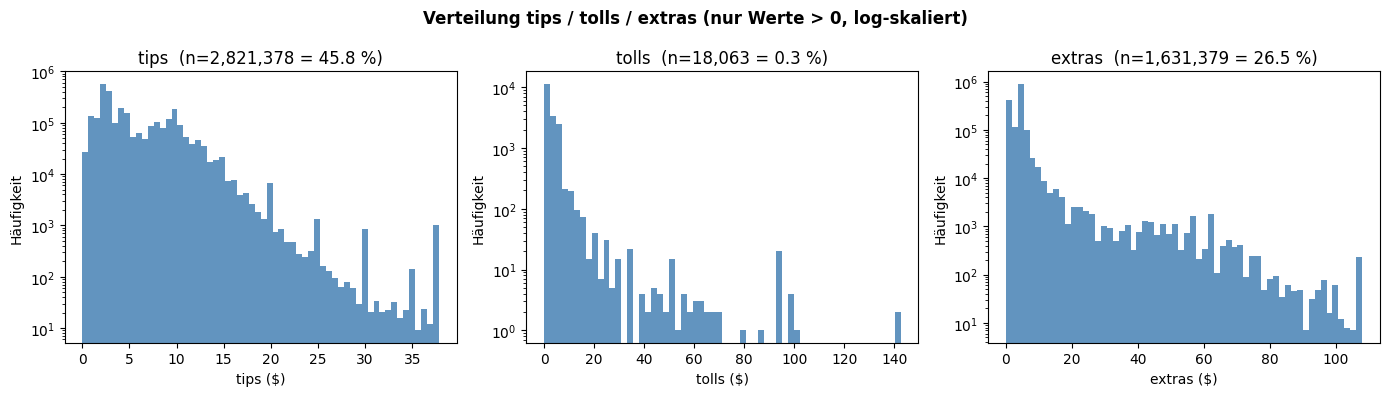


Negative tips/tolls/extras entfernt: 0 Zeilen → verbleiben 6,163,798


In [10]:
tte_cols = ['tips', 'tolls', 'extras']

print(f"{'Spalte':<10} {'Null':>8} {'Negativ':>10} {'= 0':>10} {'> 0':>10} {'Median':>8} {'Max':>8}")
print("-" * 66)
for col in tte_cols:
    n_null = df[col].isna().sum()
    n_neg  = (df[col] < 0).sum()
    n_zero = (df[col] == 0).sum()
    n_pos  = (df[col] > 0).sum()
    med    = df[col].median()
    mx     = df[col].max()
    print(f"{col:<10} {n_null:>8,} {n_neg:>10,} {n_zero:>10,} {n_pos:>10,} {med:>8.2f} {mx:>8.2f}")

print(f"\n→ tips = 0 ist normal: Barzahlungen werden ohne Trinkgeld erfasst.")
print(f"  tolls = 0 und extras = 0 sind ebenfalls häufig – nur mautpflichtige Strecken/Sonderzuschläge.")

# Verteilung der positiven Werte
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Verteilung tips / tolls / extras (nur Werte > 0, log-skaliert)", fontsize=12, fontweight='bold')
for ax, col in zip(axes, tte_cols):
    pos_data = df[col][df[col] > 0].dropna()
    if len(pos_data) == 0:
        ax.set_visible(False)
        continue
    p999 = pos_data.quantile(0.999)
    ax.hist(pos_data.clip(upper=p999 * 1.5), bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(f"{col}  (n={len(pos_data):,} = {len(pos_data)/len(df)*100:.1f} %)")
    ax.set_xlabel(f'{col} ($)')
    ax.set_ylabel('Häufigkeit')
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Negative Werte entfernen
before = len(df)
df = df[(df['tips'] >= 0) & (df['tolls'] >= 0) & (df['extras'] >= 0)].copy()
print(f"\nNegative tips/tolls/extras entfernt: {before - len(df):,} Zeilen → verbleiben {len(df):,}")

### Schritt 3d: Kategoriale Spalten – payment_type & company

Diese Spalten enthalten keine filterbaren Fehler, aber ein Blick auf die Werteverteilung zeigt unerwartete Kategorien oder einen hohen Null-Anteil. Fehlende Werte bleiben erhalten — ob und wie wir sie behandeln, entscheidet sich analysespezifisch.

=== payment_type ===
Fehlend: 0  (0.00 %)

payment_type
Credit Card    2105988
Mobile         1736137
Cash           1398502
Prcard          691642
Unknown         210467
No Charge        18068
Dispute           2971
Prepaid             23

=== company (Top 20) ===
Fehlend: 0  (0.00 %)

company
Flash Cab                            1243036
Taxicab Insurance Agency Llc          770589
Sun Taxi                              666988
City Service                          651570
Taxi Affiliation Services             478140
Transit Administrative Center Inc     433377
Chicago Independents                  397011
5 Star Taxi                           323896
Blue Ribbon Taxi Association          301455
Globe Taxi                            201566
Tac - Yellow Cab Association          184797
Medallion Leasin                      142005
Choice Taxi Association Inc           103941
Chicago City Taxi Association          40024
Wolley Taxi                            32144
Taxicab Insurance Agency, LLC

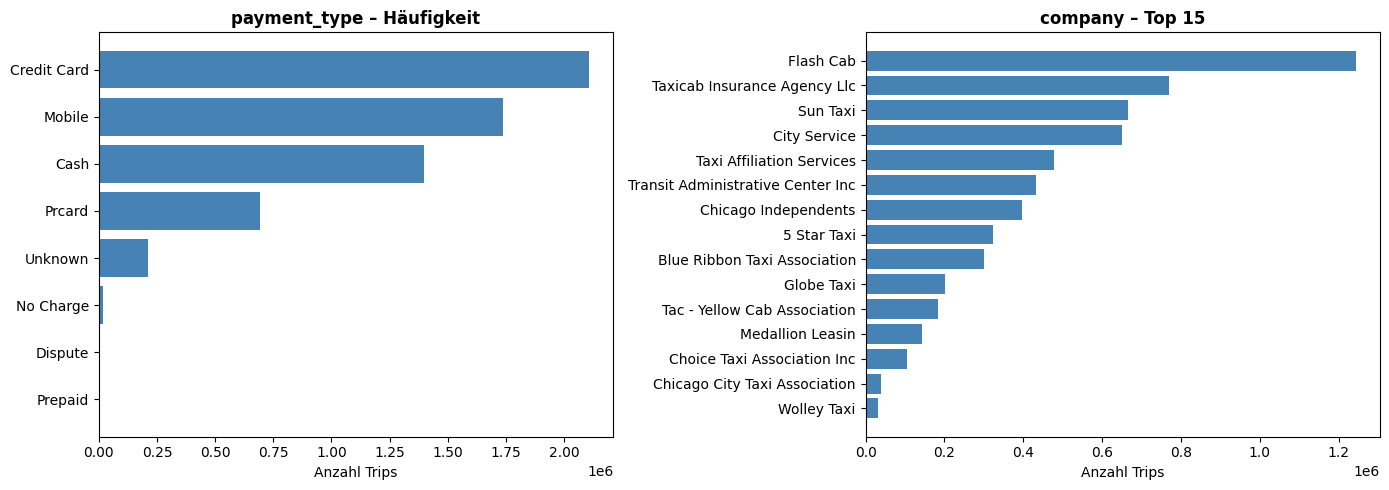


→ Keine Filterung – fehlende Werte in payment_type/company bleiben als NaN erhalten.


In [11]:
# payment_type
print("=== payment_type ===")
n_null_pt = df['payment_type'].isna().sum()
print(f"Fehlend: {n_null_pt:,}  ({n_null_pt/len(df)*100:.2f} %)\n")
print(df['payment_type'].value_counts(dropna=False).to_string())

# company
print("\n=== company (Top 20) ===")
n_null_co = df['company'].isna().sum()
print(f"Fehlend: {n_null_co:,}  ({n_null_co/len(df)*100:.2f} %)\n")
print(df['company'].value_counts(dropna=False).head(20).to_string())

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pt_plot = df['payment_type'].value_counts(dropna=False).head(10)
axes[0].barh(pt_plot.index.astype(str), pt_plot.values, color='steelblue')
axes[0].set_title('payment_type – Häufigkeit', fontweight='bold')
axes[0].set_xlabel('Anzahl Trips')
axes[0].invert_yaxis()

co_plot = df['company'].value_counts(dropna=False).head(15)
axes[1].barh(co_plot.index.astype(str), co_plot.values, color='steelblue')
axes[1].set_title('company – Top 15', fontweight='bold')
axes[1].set_xlabel('Anzahl Trips')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n→ Keine Filterung – fehlende Werte in payment_type/company bleiben als NaN erhalten.")

### Schritt 4: Ausreißer – Visualisierung & Kappung

Negative oder Null-Werte sind physikalisch unmöglich (kein Trip mit 0 Meilen oder 0 Sekunden). Sehr hohe Werte *können* echte Langstreckentrips sein, sind aber oft Datenfehler. Bevor wir kappen, schauen wir uns die Verteilungen und Perzentile an.

Spalte                    Min      P50      P95      P99    P99.9        Max
----------------------------------------------------------------------
trip_miles                0.0      3.1     18.0     23.2     33.2      781.6
trip_seconds              1.0    841.0   3126.0   4531.0   9338.3    86400.0
fare                      0.0     13.3     49.8     69.2    100.0     7777.0
trip_total                0.0     15.5     62.7     83.4    117.9     7777.0


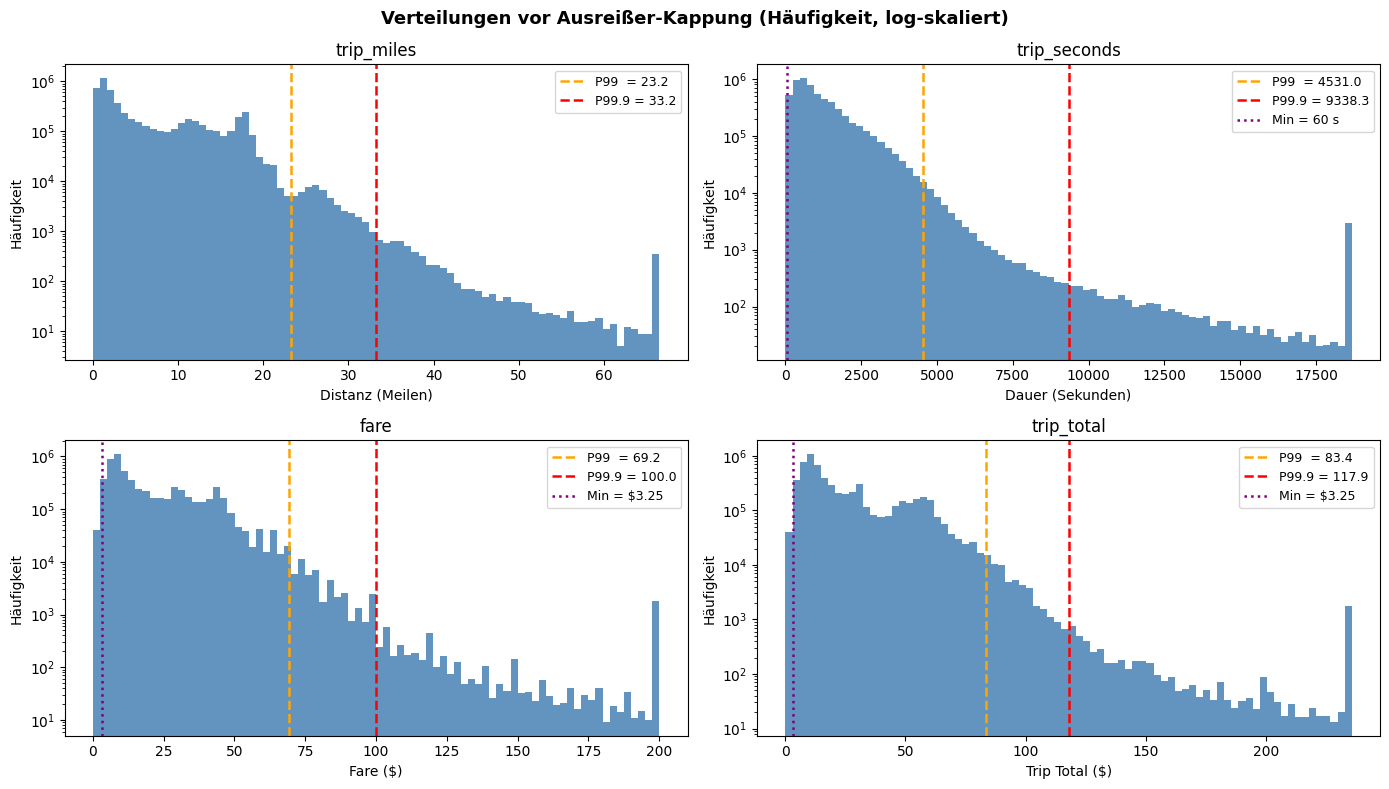


Trips unter 60 s Fahrtdauer:          323,483  (5.25 %)
  → Zu kurz für einen realen Taxitrip (Ein-/Ausstieg, Bezahlung).

Trips mit Fare < $3.25 (unter Grundtarif):  55,009  (0.89 %)
Trips mit Trip Total < $3.25:               54,510  (0.88 %)
  → Chicagoer Flag Drop (Grundtarif beim Einsteigen) beträgt $3.25.
    Alles darunter ist ein abgebrochener, Test- oder Fehler-Eintrag.

→ Untergrenzen: trip_seconds ≥ 60, fare ≥ $3.25, trip_total ≥ $3.25.
  Obergrenzen: trip_miles und trip_seconds am 99,9. Perzentil.


In [12]:
# Chicagoer Taxi-Grundtarif (Flag Drop): $3.25 – jeder Fare/Trip-Total darunter ist ungültig
MIN_FARE = 3.25
MIN_SECONDS = 60

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Verteilungen vor Ausreißer-Kappung (Häufigkeit, log-skaliert)", fontsize=13, fontweight='bold')

metrics = [
    ('trip_miles',   'Distanz (Meilen)',  axes[0, 0]),
    ('trip_seconds', 'Dauer (Sekunden)',  axes[0, 1]),
    ('fare',         'Fare ($)',          axes[1, 0]),
    ('trip_total',   'Trip Total ($)',    axes[1, 1]),
]

print(f"{'Spalte':<20} {'Min':>8} {'P50':>8} {'P95':>8} {'P99':>8} {'P99.9':>8} {'Max':>10}")
print("-" * 70)

for col, label, ax in metrics:
    data = df[col][df[col] > 0]
    p95, p99, p999 = data.quantile([0.95, 0.99, 0.999])

    print(f"{col:<20} {data.min():>8.1f} {data.median():>8.1f} {p95:>8.1f} {p99:>8.1f} {p999:>8.1f} {data.max():>10.1f}")

    clip_max = p999 * 2
    ax.hist(data.clip(upper=clip_max), bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(p99,  color='orange', linewidth=1.8, linestyle='--', label=f'P99  = {p99:.1f}')
    ax.axvline(p999, color='red',    linewidth=1.8, linestyle='--', label=f'P99.9 = {p999:.1f}')

    if col == 'trip_seconds':
        ax.axvline(MIN_SECONDS, color='purple', linewidth=1.8, linestyle=':', label=f'Min = {MIN_SECONDS} s')
    elif col in ('fare', 'trip_total'):
        ax.axvline(MIN_FARE, color='purple', linewidth=1.8, linestyle=':', label=f'Min = ${MIN_FARE}')

    ax.set_xlabel(label)
    ax.set_ylabel('Häufigkeit')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Untergrenzen-Checks
under_60s   = (df['trip_seconds'] < MIN_SECONDS).sum()
under_fare  = (df['fare']         < MIN_FARE).sum()
under_total = (df['trip_total']   < MIN_FARE).sum()

print(f"\nTrips unter {MIN_SECONDS} s Fahrtdauer:          {under_60s:,}  ({under_60s/len(df)*100:.2f} %)")
print(f"  → Zu kurz für einen realen Taxitrip (Ein-/Ausstieg, Bezahlung).")
print(f"\nTrips mit Fare < ${MIN_FARE} (unter Grundtarif):  {under_fare:,}  ({under_fare/len(df)*100:.2f} %)")
print(f"Trips mit Trip Total < ${MIN_FARE}:               {under_total:,}  ({under_total/len(df)*100:.2f} %)")
print(f"  → Chicagoer Flag Drop (Grundtarif beim Einsteigen) beträgt $3.25.")
print(f"    Alles darunter ist ein abgebrochener, Test- oder Fehler-Eintrag.")
print(f"\n→ Untergrenzen: trip_seconds ≥ {MIN_SECONDS}, fare ≥ ${MIN_FARE}, trip_total ≥ ${MIN_FARE}.")
print(f"  Obergrenzen: trip_miles und trip_seconds am 99,9. Perzentil.")

In [13]:
before = len(df)

# Untergrenzen: physikalisch unmöglich oder unter Chicagoer Mindeststandards
df = df[
    (df['trip_miles']   >  0)          &
    (df['trip_seconds'] >= MIN_SECONDS) &
    (df['fare']         >= MIN_FARE)    &
    (df['trip_total']   >= MIN_FARE)
].copy()
after_lower = len(df)
print(f"Untergrenze-Filter entfernt: {before - after_lower:,} Zeilen")
print(f"  (trip_miles > 0, trip_seconds ≥ {MIN_SECONDS} s, fare ≥ ${MIN_FARE}, trip_total ≥ ${MIN_FARE})")

# Obergrenzen: 99,9. Perzentil
cap_miles   = df['trip_miles'].quantile(0.999)
cap_seconds = df['trip_seconds'].quantile(0.999)
df = df[(df['trip_miles'] <= cap_miles) & (df['trip_seconds'] <= cap_seconds)].copy()

removed_upper = after_lower - len(df)
print(f"\nAusreißer-Filter entfernt:   {removed_upper:,} Zeilen")
print(f"  Kappgrenze Distanz: {cap_miles:.1f} Meilen")
print(f"  Kappgrenze Dauer:   {cap_seconds/60:.0f} Minuten")
print(f"\nGesamt entfernt: {before - len(df):,} ({(before - len(df))/before*100:.1f} %)")
print(f"Verbleiben:      {len(df):,} Zeilen")

Untergrenze-Filter entfernt: 501,151 Zeilen
  (trip_miles > 0, trip_seconds ≥ 60 s, fare ≥ $3.25, trip_total ≥ $3.25)

Ausreißer-Filter entfernt:   10,296 Zeilen
  Kappgrenze Distanz: 33.2 Meilen
  Kappgrenze Dauer:   148 Minuten

Gesamt entfernt: 511,447 (8.3 %)
Verbleiben:      5,652,351 Zeilen


### Ergebnis & Speichern

**Rohdatensatz:** 6.825.838 Zeilen × 21 Spalten

| Schritt | Entfernte Zeilen | Begründung |
|---------|----------------:|------------|
| 1 (Hinweis) | – | Census Tracts: ~55 % fehlend, bleiben erhalten; für vollflächige Analysen → Community Areas |
| 2 | **651.119** (9,5 %) | Kein Community Area → außerhalb Chicago; davon 94,6 % ohne Koordinaten |
| 2b | – | CA-Centroid-Mapping erstellt (77 Community Areas, Koordinaten-Std = 0,0 ✓) |
| 3 | **10.650** (0,2 %) | Fehlende Kernwerte: fare (10.095), trip_total (10.095), trip_seconds (964), trip_miles (43) |
| 3b | **271** (< 0,01 %) | Doppelte trip_id – erster Eintrag behalten |
| 3c | **0** | Keine negativen tips/tolls/extras vorhanden |
| 3d | – | payment_type/company: keine Filterung, NaN bleibt erhalten |
| 4 – Untergrenzen | **501.151** (8,1 %) | trip_miles > 0, trip_seconds ≥ 60 s, fare ≥ $3.25, trip_total ≥ $3.25 |
| 4 – Obergrenzen | **10.296** (0,2 %) | Ausreißer > P99.9: Distanz > 33,2 Meilen oder Dauer > 148 Minuten |
| **Gesamt entfernt** | **1.173.487** (17,2 %) | |
| **Verbleiben** | **5.652.351 Zeilen** | 25 Spalten, gespeichert als 356,9 MB Parquet |

Das bereinigte Dataset wird als **Parquet** gespeichert – deutlich kompakter und schneller ladbar als CSV.

In [14]:
df.to_parquet(OUT_PARQUET, index=False)
size_mb = os.path.getsize(OUT_PARQUET) / 1e6
print(f"Gespeichert: {OUT_PARQUET}")
print(f"  Zeilen:  {len(df):,}")
print(f"  Spalten: {df.shape[1]}")
print(f"  Größe:   {size_mb:.1f} MB")

Gespeichert: ../data/chicago_taxi_2025_clean.parquet
  Zeilen:  5,652,351
  Spalten: 25
  Größe:   356.9 MB
